### Multimodal RAG (PDF With Images)

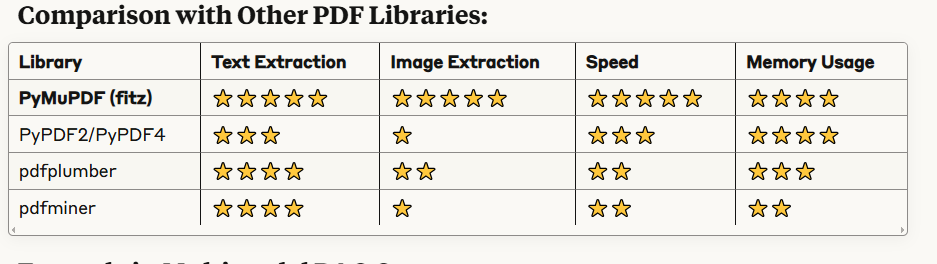

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

from imports import *

load_dotenv()

Project Root: d:\Practice\AI\RAG-Bootcamp


Matplotlib is building the font cache; this may take a moment.


True

In [3]:
import PIL
print(PIL.__version__)

import sys
print(sys.executable)

12.3.0
c:\Users\SHAILENDRA\anaconda3\envs\env_langchain\python.exe


In [4]:
# ============================================================
# Step 2 - Initialize AI Models
# ============================================================

# ---------- OpenAI Client ----------
# Used for interacting with GPT-4o (Multimodal LLM)

client = OpenAI()

# ---------- Text Embedding Model ----------
# Converts text into dense vectors

text_embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

# ---------- CLIP Image Embedding Model ----------
# Converts images into dense vectors

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# ---------- CLIP Processor ----------
# Preprocesses images before passing them to CLIP

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# ============================================================
# Verify Models
# ============================================================

print("=" * 60)
print("Models Initialized Successfully")
print("=" * 60)

print(f"OpenAI Embedding Model : text-embedding-3-small")
print(f"CLIP Model             : openai/clip-vit-base-patch32")
print(f"LLM                    : GPT-4o")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 15901.89it/s]
c:\Users\SHAILENDRA\anaconda3\envs\env_langchain\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SHAILENDRA\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Models Initialized Successfully
OpenAI Embedding Model : text-embedding-3-small
CLIP Model             : openai/clip-vit-base-patch32
LLM                    : GPT-4o


In [9]:
# ============================================================
# Step 3 - Load PDF
# ============================================================

# Path to PDF
pdf_path = "Multimodal_example.pdf"      # <-- Change this path

# Open PDF
pdf_document = fitz.open(pdf_path)

# ============================================================
# Verify PDF
# ============================================================

print("=" * 60)
print("PDF Loaded Successfully")
print("=" * 60)

print(f"File Name     : {Path(pdf_path).name}")
print(f"Total Pages   : {pdf_document.page_count}")
print(f"Metadata      :")
print(pdf_document.metadata)

PDF Loaded Successfully
File Name     : Multimodal_example.pdf
Total Pages   : 10
Metadata      :
{'format': 'PDF 1.5', 'title': 'MMCIG: Multimodal Cover Image Generation for Text-only Documents and Its Dataset Construction via Pseudo-labeling', 'author': 'Hyeyeon Kim; Sungwoo Han; Jingun Kwon; Hidetaka Kamigaito; Manabu Okumura', 'subject': '', 'keywords': '', 'creator': 'arXiv GenPDF (tex2pdf:)', 'producer': 'pikepdf 8.15.1', 'creationDate': '', 'modDate': '', 'trapped': '', 'encryption': None}


In [10]:
# ============================================================
# Step 4 - Extract Text from PDF
# ============================================================

documents = []

for page_number in range(pdf_document.page_count):

    # Load current page
    page = pdf_document.load_page(page_number)

    # Extract text
    text = page.get_text()

    # Skip empty pages
    if text.strip():

        documents.append(
            Document(
                page_content=text,
                metadata={
                    "source": pdf_path,
                    "page": page_number + 1,
                    "type": "text"
                }
            )
        )

print("=" * 60)
print("Text Extraction Completed")
print("=" * 60)

print(f"Total Text Documents : {len(documents)}")

Text Extraction Completed
Total Text Documents : 10


## Check what type of PDF it is

In [8]:
page = pdf_document.load_page(0)

print("Text Length :", len(page.get_text()))
print("Images      :", len(page.get_images(full=True)))

Text Length : 0
Images      : 1


## PDF is image-based (scanned PDF).
Text Length : 0
Images      : 1

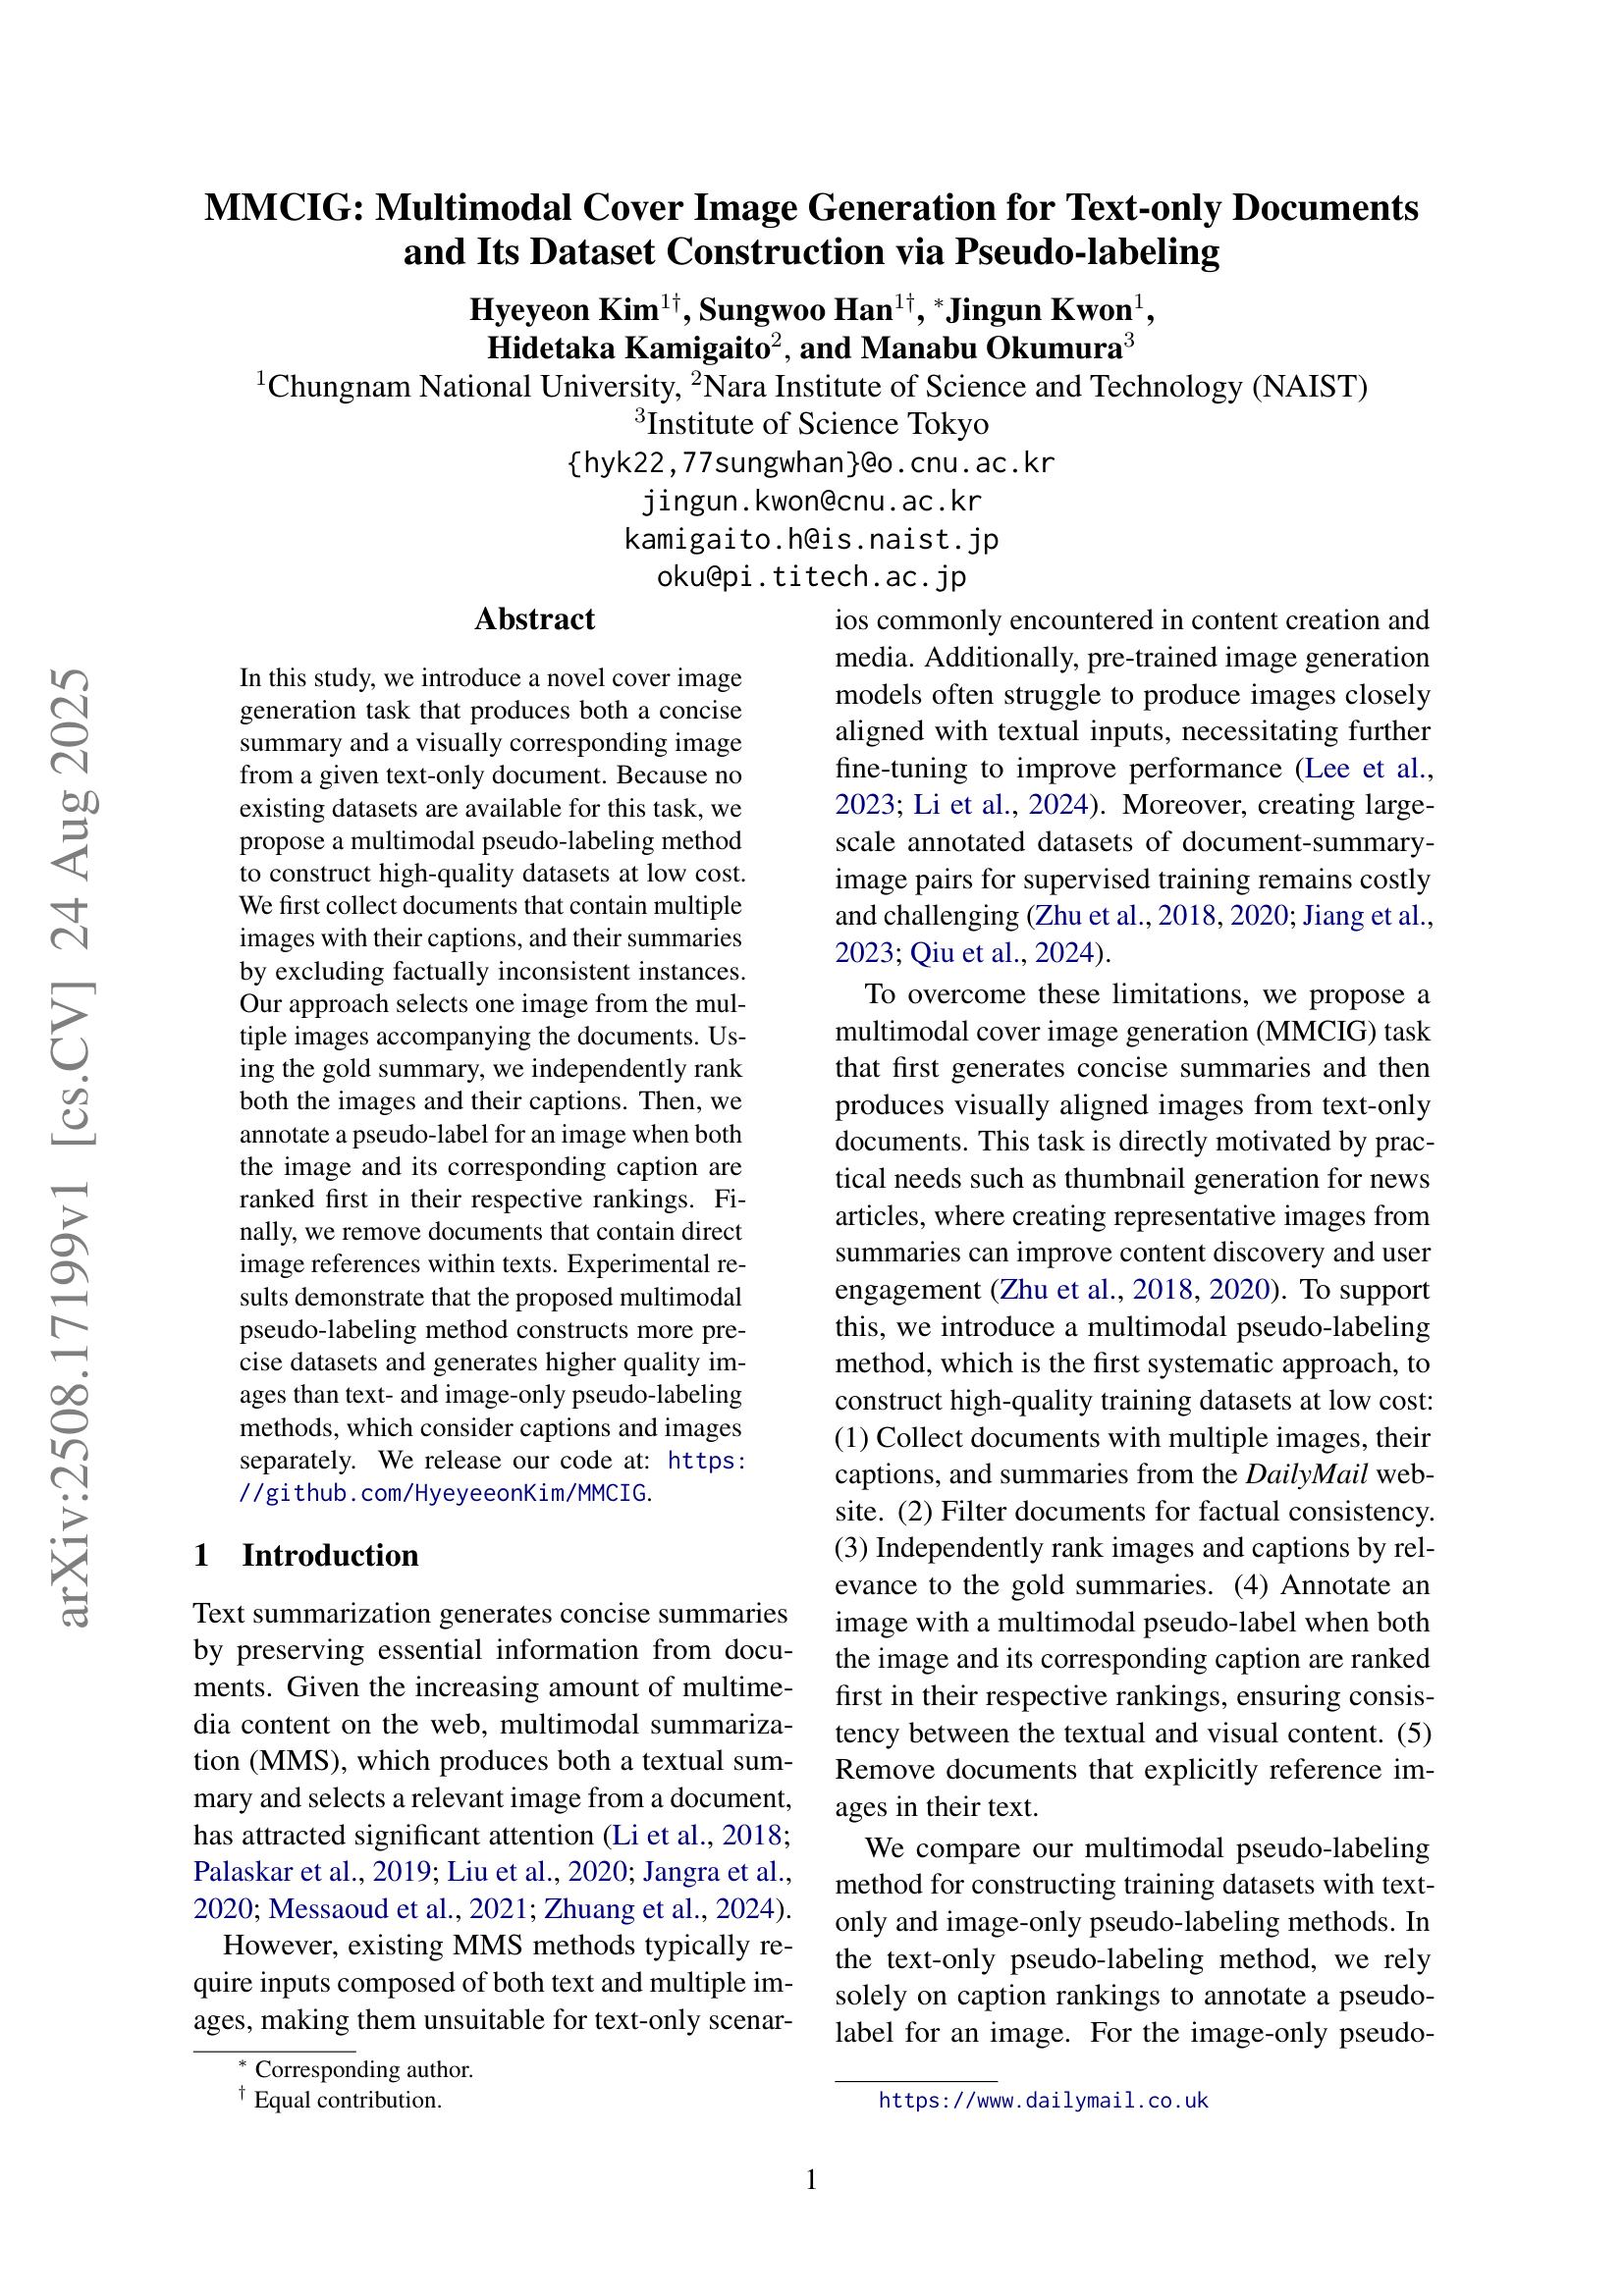

In [14]:
page = pdf_document.load_page(0)

pix = page.get_pixmap(dpi=200)

img = Image.frombytes(
    "RGB",
    [pix.width, pix.height],
    pix.samples
)

display(img)

In [16]:
# ============================================================
# Step 4 - Extract Images From PDF
# ============================================================

import io

images = []

for page_number in range(pdf_document.page_count):

    page = pdf_document.load_page(page_number)

    image_list = page.get_images(full=True)

    print(f"Page {page_number + 1}: {len(image_list)} image(s)")

    for image_index, image in enumerate(image_list):

        xref = image[0]

        base_image = pdf_document.extract_image(xref)

        image_bytes = base_image["image"]

        image_ext = base_image["ext"]

        pil_image = Image.open(io.BytesIO(image_bytes))

        images.append(
            {
                "page": page_number + 1,
                "image_index": image_index + 1,
                "image": pil_image,
                "extension": image_ext,
            }
        )

print("\nTotal Images:", len(images))

Page 1: 0 image(s)
Page 2: 0 image(s)
Page 3: 0 image(s)
Page 4: 2 image(s)
Page 5: 0 image(s)
Page 6: 0 image(s)
Page 7: 0 image(s)
Page 8: 1 image(s)
Page 9: 1 image(s)
Page 10: 2 image(s)

Total Images: 6


In [19]:
# ============================================================
# Step 5 - Generate Image Embeddings
# ============================================================

image_embeddings = []

for img in images:

    # Preprocess image
    inputs = clip_processor(
        images=img["image"],
        return_tensors="pt"
    )

    # Generate image embedding
    with torch.no_grad():

        output = clip_model.get_image_features(**inputs)

        # Handle different Transformers versions
        if isinstance(output, torch.Tensor):
            embedding = output

        elif hasattr(output, "pooler_output"):
            embedding = output.pooler_output

        elif hasattr(output, "image_embeds"):
            embedding = output.image_embeds

        else:
            raise ValueError(
                f"Unsupported output type: {type(output)}"
            )

    # Normalize embedding
    embedding = embedding / embedding.norm(dim=-1, keepdim=True)

    image_embeddings.append(
        {
            "page": img["page"],
            "image_index": img["image_index"],
            "image": img["image"],
            "embedding": embedding.squeeze().cpu().numpy()
        }
    )

print("=" * 60)
print("Image Embeddings Generated Successfully")
print("=" * 60)

print(f"Total Images      : {len(image_embeddings)}")
print(f"Embedding Shape   : {image_embeddings[0]['embedding'].shape}")

Image Embeddings Generated Successfully
Total Images      : 6
Embedding Shape   : (512,)


In [18]:
import transformers

print(transformers.__version__)
type(clip_model.get_image_features(**inputs))

5.14.1


transformers.modeling_outputs.BaseModelOutputWithPooling

In [20]:
# ============================================================
# Step 6 - Build Image Vector Database
# ============================================================

import faiss
import numpy as np

# Collect all image embeddings

embedding_matrix = np.array(
    [img["embedding"] for img in image_embeddings],
    dtype="float32"
)

print("=" * 60)
print("Embedding Matrix")
print("=" * 60)

print("Shape :", embedding_matrix.shape)

Embedding Matrix
Shape : (6, 512)


In [21]:
# Embedding dimension

dimension = embedding_matrix.shape[1]

# Cosine similarity
# Since vectors are normalized,
# Inner Product == Cosine Similarity

index = faiss.IndexFlatIP(dimension)

index.add(embedding_matrix)

print("=" * 60)
print("FAISS Index Created")
print("=" * 60)

print("Total Images Indexed :", index.ntotal)

FAISS Index Created
Total Images Indexed : 6


In [22]:
# ============================================================
# Step 7 - Convert User Query into CLIP Text Embedding
# ============================================================

query = "Show me the architecture diagram"

inputs = clip_processor(
    text=[query],
    return_tensors="pt",
    padding=True
)

with torch.no_grad():

    output = clip_model.get_text_features(**inputs)

    # Handle different Transformers versions
    if isinstance(output, torch.Tensor):
        text_embedding = output

    elif hasattr(output, "pooler_output"):
        text_embedding = output.pooler_output

    elif hasattr(output, "text_embeds"):
        text_embedding = output.text_embeds

    else:
        raise ValueError(f"Unsupported output type: {type(output)}")

# Normalize

text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

text_embedding = text_embedding.cpu().numpy().astype("float32")

print("=" * 60)
print("Text Embedding Created")
print("=" * 60)

print(text_embedding.shape)

Text Embedding Created
(1, 512)


In [23]:
# ============================================================
# Step 7 - Search Similar Images
# ============================================================

top_k = 3

scores, indices = index.search(
    text_embedding,
    top_k
)

print("=" * 60)
print("Search Results")
print("=" * 60)

print("Scores :", scores)
print("Indices:", indices)

Search Results
Scores : [[0.24877366 0.21128291 0.18877947]]
Indices: [[2 3 4]]


Rank      : 1
Page      : 8
Similarity: 0.2488


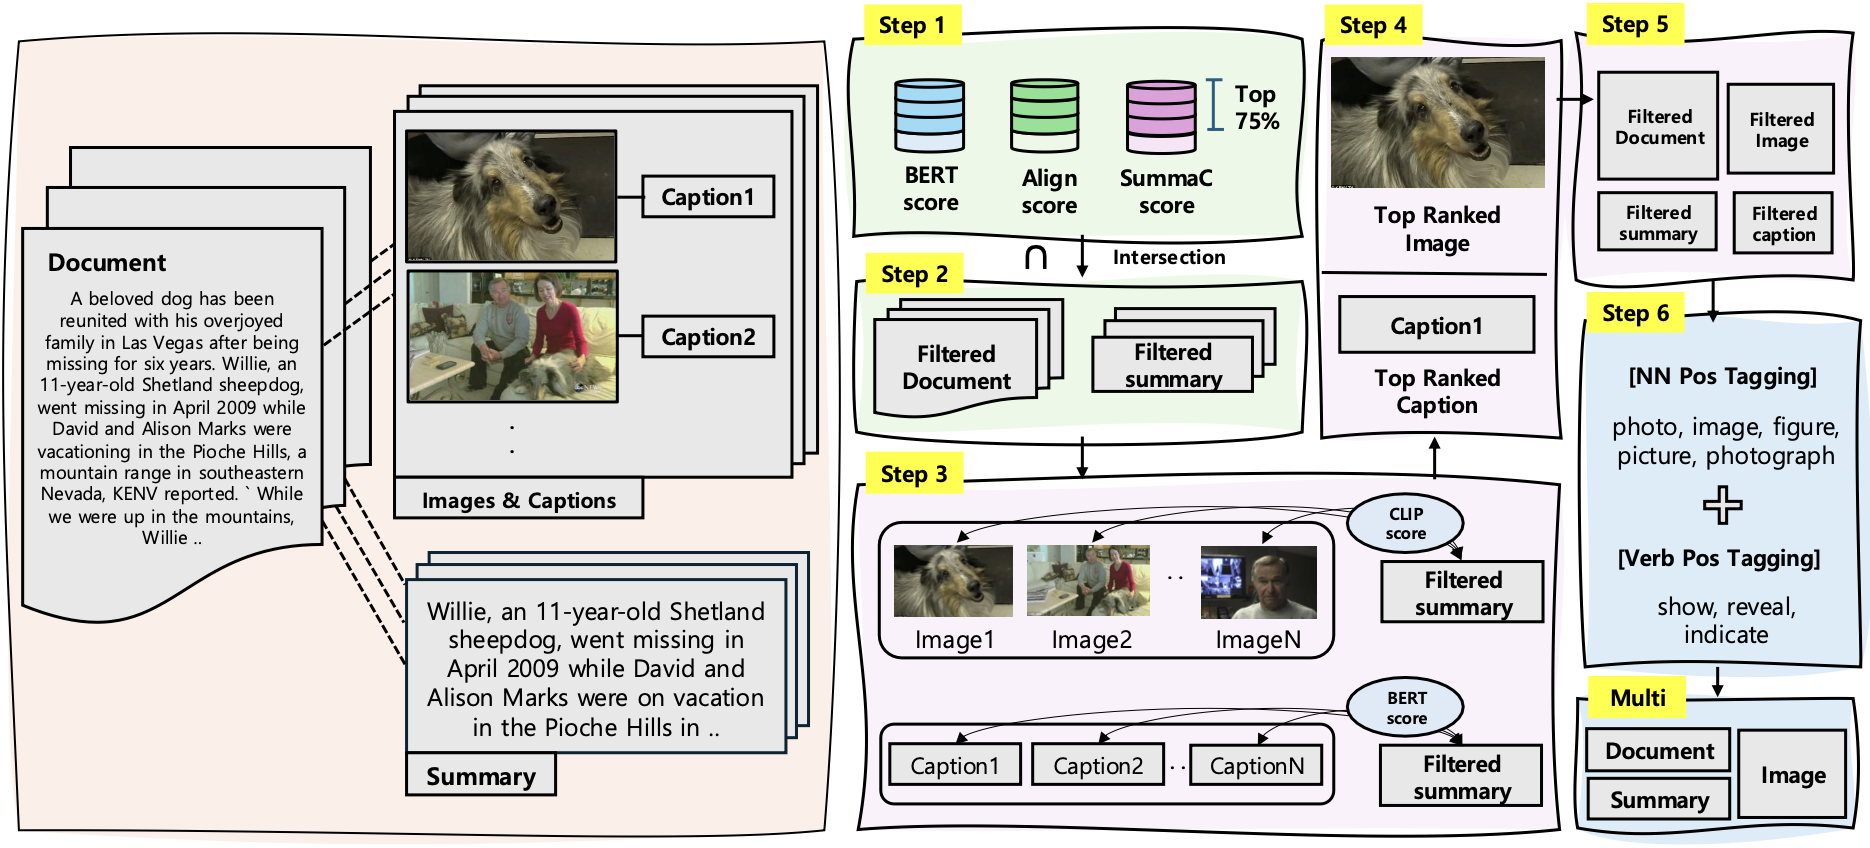

Rank      : 2
Page      : 9
Similarity: 0.2113


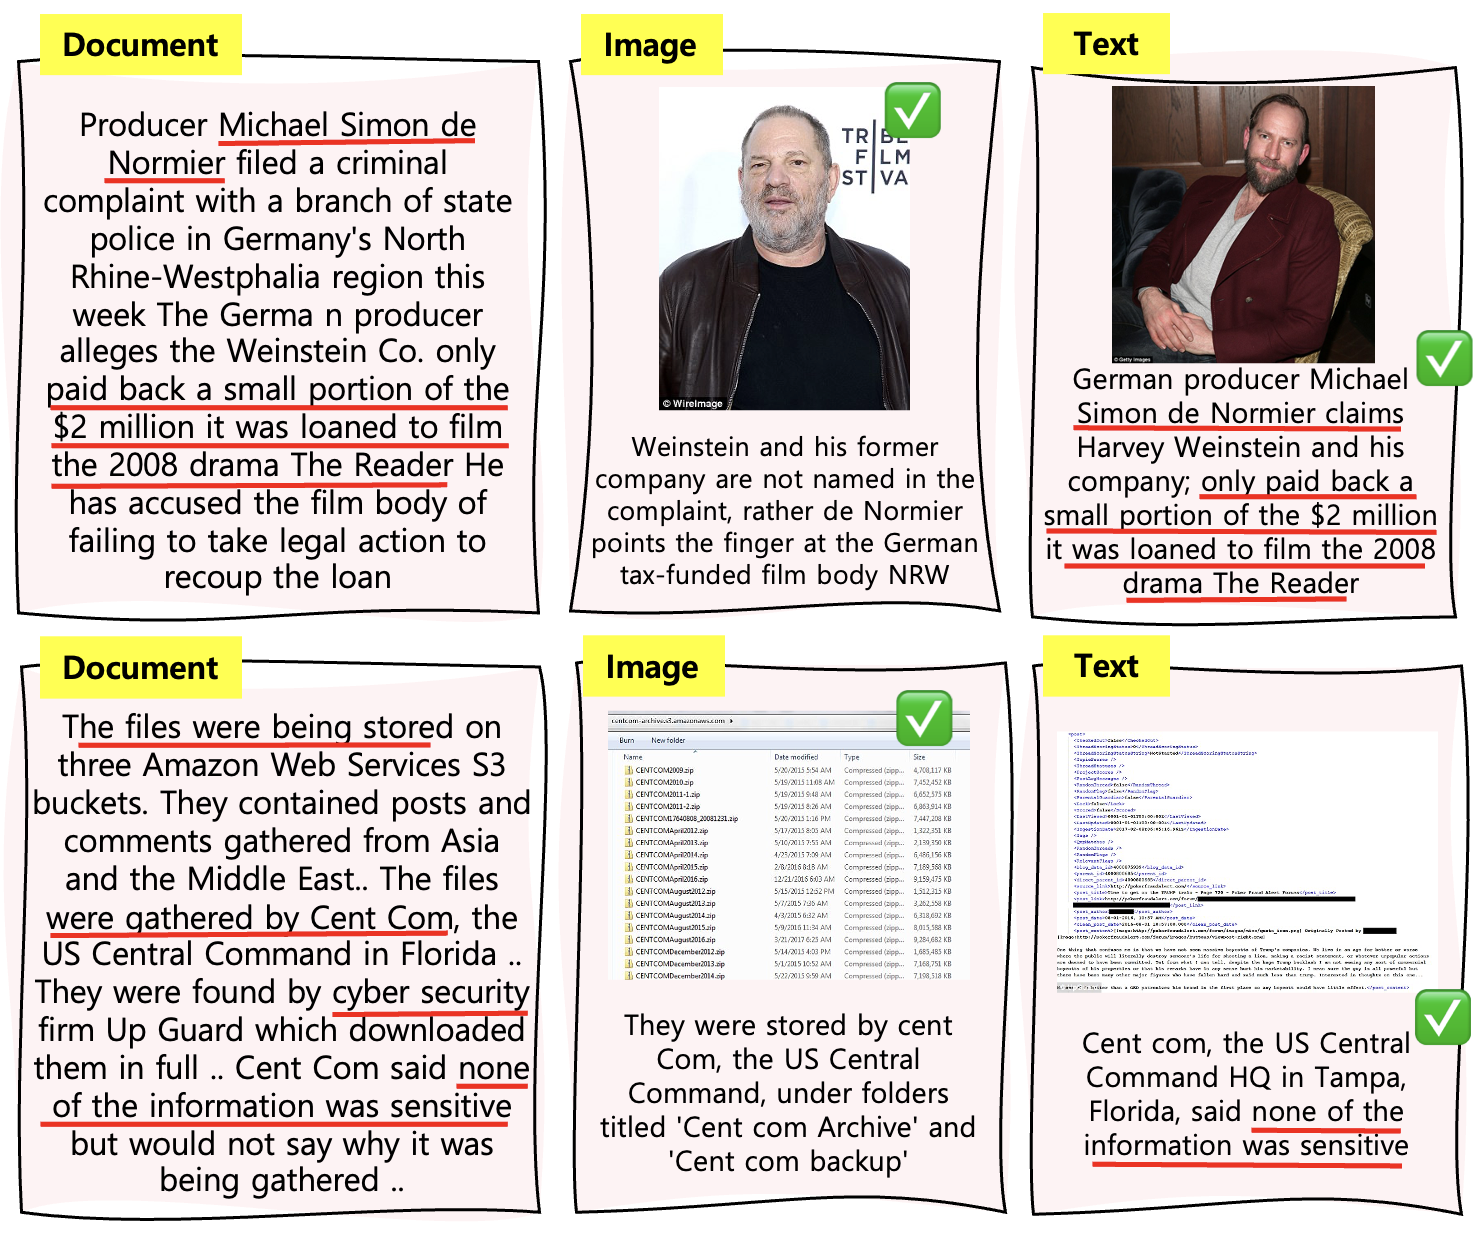

Rank      : 3
Page      : 10
Similarity: 0.1888


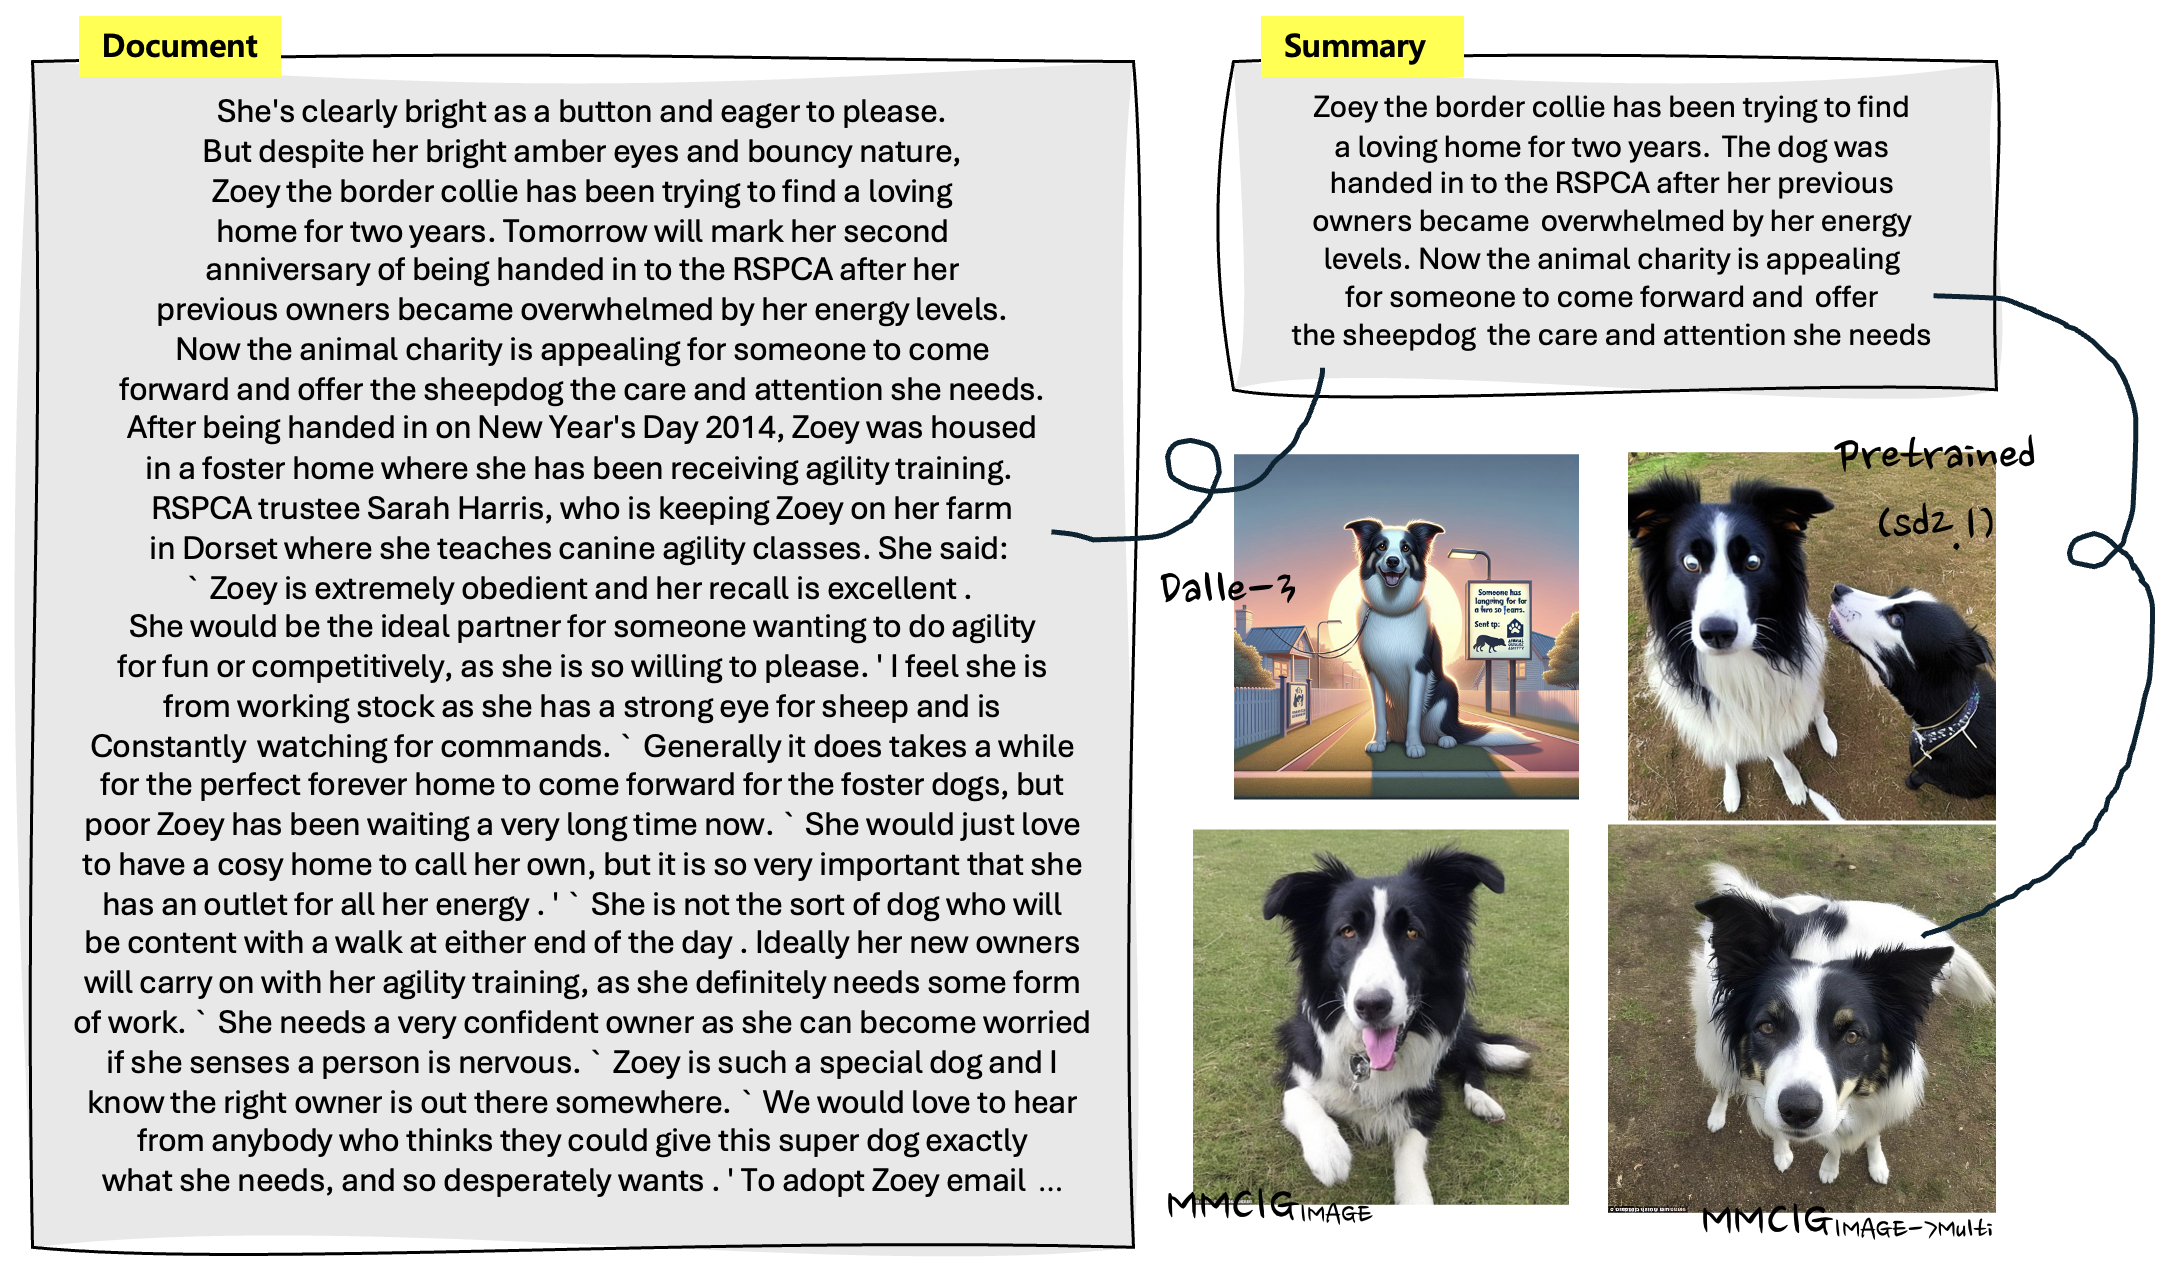

In [24]:
# ============================================================
# Display Retrieved Images
# ============================================================

for rank, idx in enumerate(indices[0]):

    img = image_embeddings[idx]

    print("=" * 60)
    print(f"Rank      : {rank + 1}")
    print(f"Page      : {img['page']}")
    print(f"Similarity: {scores[0][rank]:.4f}")

    display(img["image"])

In [25]:
# ============================================================
# Step 8 - Helper Function
# Convert PIL Image -> Base64
# ============================================================

import base64
import io


def image_to_base64(image):

    buffer = io.BytesIO()

    image.save(buffer, format="PNG")

    return base64.b64encode(buffer.getvalue()).decode("utf-8")

In [ ]:
# ============================================================
# Prepare Retrieved Images
# ============================================================

vision_images = []
print("=" * 60)
print("Preparing Images for GPT-4o Vision")
for idx in indices[0]:

    img = image_embeddings[idx]["image"]

    image_base64 = image_to_base64(img)

    vision_images.append(
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{image_base64}"
            }
        }
    )

print(f"Images prepared : {len(vision_images)}")

Images prepared : 3


In [27]:
# ============================================================
# Ask GPT-4o Vision
# ============================================================

question = "Explain the architecture diagram."

response = client.chat.completions.create(

    model="gpt-4o",

    messages=[

        {
            "role": "user",

            "content": [

                {
                    "type": "text",
                    "text": question
                },

                *vision_images

            ]
        }

    ]

)

print("=" * 60)
print("GPT-4o Response")
print("=" * 60)

print(response.choices[0].message.content)

GPT-4o Response
The architecture diagrams illustrate a multi-step process for summarizing and associating images with documents. Here's an explanation of each component:

### Diagram 1: Text and Image Alignment Process

1. **Document and Images & Captions**: The system processes a document and associated images with captions.

2. **Step 1 (Scores Calculation)**:
   - **BERT Score, Align Score, SummaC Score**: Each document is assessed using different scoring models. These scores help filter content, retaining the top 75% by score, which indicates relevance and quality.
   - The intersection of these scores is used to filter the document and summary.

3. **Step 2 (Filtering)**:
   - Results in a filtered document and summary that best match the intent and content of the inputs.

4. **Step 3 (Image and Caption Scoring)**:
   - Images and captions undergo a CLIP score assessment to align them with filtered summaries based on context and relevance.
   - Again, a BERT score helps filter sum

In [28]:
# ============================================================
# Ask GPT-4o Vision
# ============================================================

question = "What is Multimodal Pseudo-labeling and show Human evaluation results."

response = client.chat.completions.create(

    model="gpt-4o",

    messages=[

        {
            "role": "user",

            "content": [

                {
                    "type": "text",
                    "text": question
                },

                *vision_images

            ]
        }

    ]

)

print("=" * 60)
print("GPT-4o Response")
print("=" * 60)

print(response.choices[0].message.content)

GPT-4o Response
Multimodal Pseudo-labeling involves using multiple modes of information (such as text and images) to improve the automatic annotation or labeling processes, typically in machine learning tasks. This approach leverages different data types to enhance label accuracy and model performance, often by incorporating both textual and visual data to generate richer datasets.

### Process Overview:
1. **Input & Initial Scoring**:
   - Documents, images, and captions are collected.
   - Scores (BERT, Align, SummaC) are generated for textual data.
   - Scores (CLIP) are generated for images and captions.
   
2. **Filtering**:
   - Textual and visual data are filtered by ranking scores to identify the most informative pairs.
   
3. **Image & Caption Ranking**:
   - Images and captions are ranked and filtered again to ensure alignment with the associated document and summary.
   
4. **Integration**:
   - The best matching image is integrated with its most relevant caption to form a c